In [53]:
import sys

sys.path.append("..")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf

from src import metrics

tickers = ["KO", "NVDA", "TSLA", "SPY", "TLT"]

raw = yf.download(tickers, start="2020-01-01", auto_adjust=True)


[*********************100%***********************]  5 of 5 completed


In [54]:
prices = raw["Close"]
ret = metrics.daily_returns(prices)
vol = metrics.ann_vol(returns=ret)

sharpe = metrics.sharpe(returns=ret)

maxdd = metrics.max_drawdown(prices=prices)
maxdu = metrics.max_drawup(prices=prices)

df = pd.DataFrame(
    {
        "Ann. ret": (1 + ret).prod() ** (252 / ret.count()) - 1,
        "Ann. vol": vol,
        "Sharpe": sharpe,
        "MaxDD": maxdd,
        "MaxDu": maxdu,
    }
)
df = df.round(3)
print(df)

        Ann. ret  Ann. vol  Sharpe  MaxDD   MaxDu
Ticker                                           
KO         0.106     0.202   0.601 -0.370   1.958
NVDA       0.718     0.518   1.302 -0.663  47.200
SPY        0.152     0.201   0.806 -0.337   2.805
TLT       -0.047     0.165  -0.209 -0.484   0.269
TSLA       0.462     0.647   0.910 -0.736  19.343


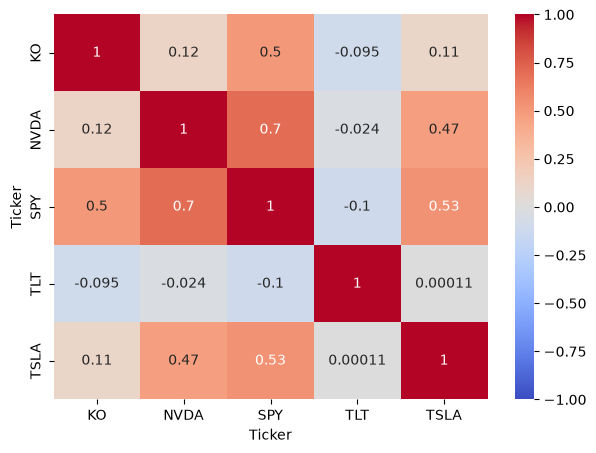

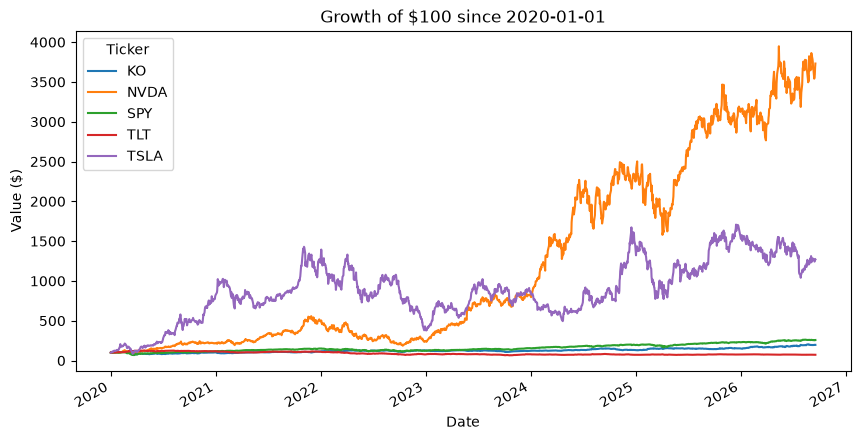

In [55]:
corr = ret.corr()


plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmax=1, vmin=-1, center=0)
plt.show()


normal = prices / prices.iloc[0] * 100
normal.plot(figsize=(10, 5), title="Growth of $100 since 2020-01-01")
plt.ylabel("Value ($)")
plt.show()

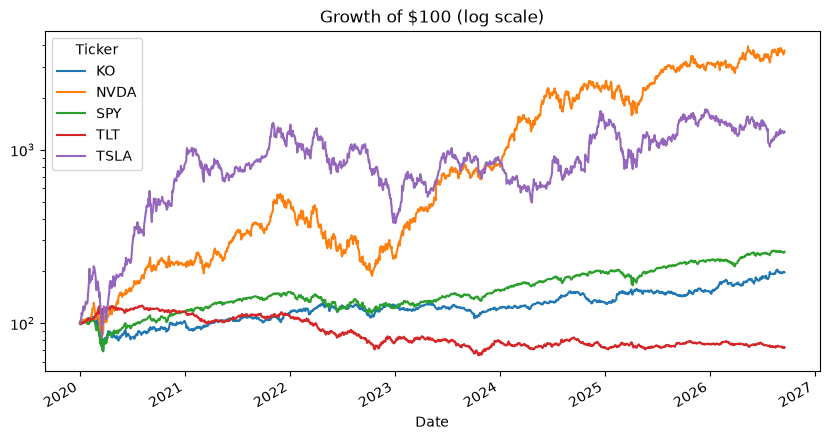

In [56]:
normal.plot(figsize=(10, 5), logy=True, title="Growth of $100 (log scale)")
plt.show()

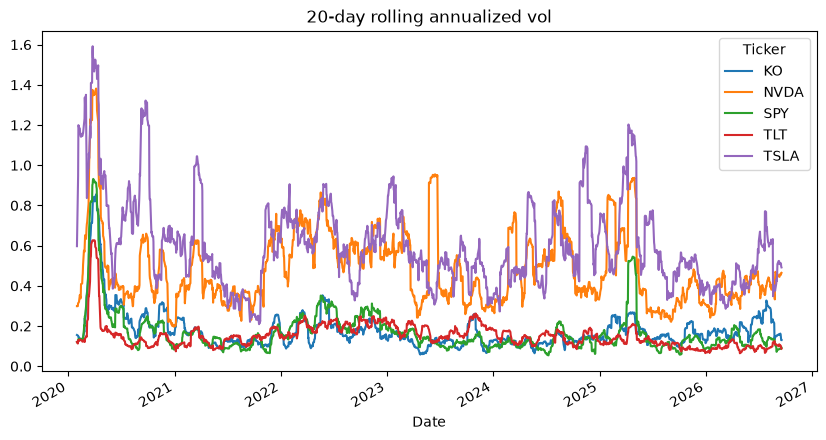

In [57]:
metrics.rolling_vol(ret, 20).plot(
    figsize=(10, 5), title="20-day rolling annualized vol"
)
plt.show()

TLT is the only genuine diversifier. From the heatmap we can see that it has a negative or nearly 0 corr with all the other stocks.
However, even though it diversifies the most it had a maxDD of -0.48 which is worse than the spy so it is also the most costly to hold.

All the stocks have a 0.5-0.7 corr meaning diversifying over these stocks gives less protection than appears. KO-TSLA and KO-NVDA are exceptions to this corr.

NVDA has the best sharpe but also the second worst drawdown. Both the metrics are important.    

Vol spikes are market wide. When covid hit they all spiked together